In [2]:
import ast
import pandas as pd
import numpy as np
import re
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from bs4 import BeautifulSoup

from catboost import CatBoostRegressor

from joblib import dump

from src.utils.kmeanscluster import KMeansCluster

from lightgbm import LGBMRegressor

from optuna import create_study

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

from time import time

from src.utils.toolbox_ML_v2 import describe_df, tipifica_variables

from src.utils.utils import obtener_urls, aplanar_campos_anidados, crear_features_poi, limpiar_y_crear_features, make_objective_xgb, make_objective_lgb, make_objective_cat, drop_columns

from xgboost import XGBRegressor

from src.utils import bootcampviztools as bt

pd.set_option('display.max_columns', 500)
warnings.filterwarnings('ignore')

url = 'https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC' # Mapa de la Comunidad de Madrid y alrededores
df = pd.read_csv('./src/data/pisos_madrid.csv', sep ='|')

c:\Users\phbas\Documents\Bootcamp_Data_Science\ML_Prediccion_Precio_Vivienda_Madrid\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


***Versión reducida***   
*Para obtener más información acudir a los notebook_completo en la carpeta notebooks*

# **Extracción de datos**

In [2]:
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, 'html.parser')
ultima = soup.find('a', string='>>')
max_pages = int(re.findall(r'pag-(\d+)', str(ultima))[0])

url_splited = url.split('pag-1')
data = []
for i in range(1, max_pages+1):
    subdata = obtener_urls(f'pag-{i}'.join(url_splited), df)
    data.extend(subdata)

    if len(subdata) < 15:
        break

df = pd.concat([pd.DataFrame(data), df]).reset_index(drop=True)
df.to_csv('./src/data/pisos_madrid.csv', sep='|', index=False)
df = pd.read_csv('./src/data/pisos_madrid.csv', sep ='|')

Buscando pisos en la página https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC ...
Ya lo tengo: https://www.tecnocasa.es/venta/piso/madrid/madrid/640465.html


## **Objetivo y planteamiento**

El proyecto plantea un problema de **estimación de precios inmobiliarios** a partir de anuncios publicados en la web (Tecnocasa). El objetivo es **predecir el precio de publicación en euros** utilizando información estructural y de contexto disponible en cada anuncio (por ejemplo, superficie, dormitorios, baños, ubicación y atributos del inmueble). Esta estimación permite obtener una referencia rápida del valor esperado en una zona, identificar anuncios potencialmente sobrevalorados o infravalorados y apoyar decisiones de inversión o priorización de búsqueda.

Desde el punto de vista analítico, se trata de un problema adecuado para **Machine Learning** porque el precio depende de múltiples factores que interactúan entre sí y no siguen relaciones estrictamente lineales (por ejemplo, la superficie impacta de forma distinta según la zona; ciertas prestaciones pueden incrementar el precio de manera desigual según el entorno). En este contexto, un enfoque de ML permite aprender patrones a partir de ejemplos reales, generalizar a anuncios nuevos y cuantificar el desempeño del modelo mediante métricas objetivas (MAPE).

En consecuencia, se adopta un enfoque **supervisado de regresión**, donde la variable objetivo `y` corresponde al **precio en euros** y el conjunto de entrada `X` se construye a partir de variables predictoras derivadas del anuncio, incluyendo variables numéricas y categóricas tras su limpieza y transformación. De forma complementaria, se incorpora una estrategia no supervisada como parte del *feature engineering*: se aplica **K-Means** sobre `latitud` y `longitud` para generar un **cluster geográfico** (`cluster`) que funcione como proxy de “zonas” aprendidas desde los datos. Esto permite resumir patrones espaciales relevantes y capturar efectos de micro-mercado, especialmente útil cuando no se dispone de una variable explícita de barrio o distrito, sin introducir fuga de información al no utilizar variables derivadas del propio precio.

# **Comprensión del dataset: esquema, calidad y limpieza inicial**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   dormitorios         1099 non-null   str    
 1   superficie_m2       1211 non-null   float64
 2   baños               1112 non-null   str    
 3   url                 1211 non-null   str    
 4   features            1211 non-null   str    
 5   descripcion         1211 non-null   str    
 6   precio              1211 non-null   str    
 7   latitud             1211 non-null   float64
 8   longitud            1211 non-null   float64
 9   media               1211 non-null   str    
 10  points_of_interest  1200 non-null   str    
 11  energy_data         1211 non-null   str    
dtypes: float64(3), str(9)
memory usage: 113.7 KB


In [4]:
df.head()

,dormitorios,superficie_m2,baños,url,features,descripcion,precio,latitud,longitud,media,points_of_interest,energy_data
0,3 dorm.,89.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 650259, 'floor': 8, 'floors': None, 'bo...","<p>Se vende piso con una superficie de 89 m², ...","{'price': '335.000 €', 'box_price': None, 'mor...",40.420002,-3.625273,"{'floor_plans': None, 'has_realistico': False,...","{'public_transport': [{'name': 'Alsacia', 'cla...","{'class': '', 'class_emissions': None, 'certif..."
1,2 dorm.,42.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 649692, 'floor': 'Baja', 'floors': None...",<p>Agencia inmobiliaria de MADRID - ATOCHA - D...,"{'price': '220.000 €', 'box_price': None, 'mor...",40.400802,-3.689012,"{'floor_plans': None, 'has_realistico': False,...",{'public_transport': [{'name': 'Palos de la Fr...,"{'class': 'd', 'class_emissions': 'd', 'certif..."
2,3 dorm.,71.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mej...,"{'id': 577869, 'floor': 2, 'floors': None, 'bo...",<p>Agencia inmobiliaria de Mejorada Del Campo ...,"{'price': '199.900 €', 'box_price': None, 'mor...",40.395602,-3.487472,"{'floor_plans': None, 'has_realistico': False,...","{'public_transport': [{'name': None, 'class': ...","{'class': 'e', 'class_emissions': 'e', 'certif..."
3,NaN,68.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/par...,"{'id': 641162, 'floor': '2 (planta baja)', 'fl...",<p>Agencia inmobiliaria de parla zona PARLA NO...,"{'price': '179.900 €', 'box_price': None, 'mor...",40.242002,-3.771212,"{'floor_plans': None, 'has_realistico': False,...","{'public_transport': [{'name': 'Parla', 'class...","{'class': '', 'class_emissions': None, 'certif..."
4,5 dorm.,150.0,NaN,https://www.tecnocasa.es/venta/piso/cuenca/cue...,"{'id': 650087, 'floor': '', 'floors': None, 'b...",<p>.</p>,"{'price': '259.900 €', 'box_price': None, 'mor...",40.058600,-2.122210,"{'floor_plans': None, 'has_realistico': False,...",{'public_transport': [{'name': 'Cuenca - RENFE...,"{'class': '', 'class_emissions': None, 'certif..."


Tras revisar una muestra inicial del dataset y su estructura general, observamos que el conjunto de datos está compuesto por **12 columnas** y que cada fila representa un anuncio de vivienda obtenido desde la web.

En el bloque de variables básicas de la vivienda contamos con **`dormitorios`**, **`superficie_m2`**, **`baños`**, **`latitud`** y **`longitud`**. En esta primera inspección, **`superficie_m2`** se presenta en un formato directamente utilizable, mientras que **`dormitorios`** y **`baños`** muestran valores “sucios” o inconsistentes (por ejemplo, valores en texto y/o faltantes), por lo que requerirán normalización antes de su uso en el modelado. Las variables geográficas **`latitud`** y **`longitud`** se observan ya en formato numérico (o fácilmente convertible), lo cual permite usarlas directamente como variables geográficas tras una verificación básica de tipos y valores faltantes.

Además, el dataset incluye columnas cuyo contenido no es un valor simple, sino **estructuras semiestructuradas** (diccionarios y/o elementos anidados). En este grupo se encuentran **`features`**, **`precio`**, **`media`**, **`points_of_interest`** y **`energy_data`**, y su tratamiento requerirá primero inspeccionar qué información contienen y cómo se distribuye dentro de sus claves internas.


La columna `url` se utilizará únicamente como identificador operativo durante el proceso (por ejemplo, control de duplicados) y `descripcion` no se empleará en la versión actual del proyecto.

In [5]:
df.duplicated().sum()

np.int64(0)

### **Precio**

In [6]:
df.precio[0]

'{\'price\': \'335.000 €\', \'box_price\': None, \'mortgage_payment\': \'<div class="float-left w-auto">€ 1.079 / mes &nbsp;</div><modal-opener class="modal-opener-nostyle float-left w-auto" name="calculate-mortgage"><img src="/img/icons/info.svg" alt="calcula la hipoteca"></modal-opener>\', \'mortgage_payment_value\': \'1.079\', \'expenses\': None}'

Se observa que `precio` no es un valor escalar sino un **diccionario** con múltiples claves, por ejemplo: `price`, `mortgage_payment`, `mortgage_payment_value`, entre otras.

Para el modelado se decidió **extraer únicamente la clave `price`**, ya que representa el **precio publicado** y se utilizará como **variable objetivo (target)**. El resto de campos del diccionario (por ejemplo, el pago mensual estimado de hipoteca) se descartan deliberadamente porque constituyen **variables derivadas directa o indirectamente del propio precio**.

Incluir variables como `mortgage_payment_value` implicaría una **fuga de información**: el modelo estaría recibiendo como predictor una transformación del target (dependiente del precio y de supuestos financieros), lo que produciría un rendimiento artificialmente alto en entrenamiento/validación y una capacidad de generalización engañosa.  

Por este motivo, se **extrae y normaliza únicamente el valor de `price`** para definir la **variable objetivo `y`** (precio final en euros). A continuación, la columna `precio` (y cualquier componente asociado a cálculos económicos como la hipoteca) **se elimina del dataset de variables predictoras (`X`)** antes de realizar el `train_test_split`, evitando incluir en el entrenamiento información derivada del propio precio (fuga de información / *data leakage*).

### **Dormitorios y baños**

In [7]:
print(df.dormitorios.unique().tolist())
print(df.baños.unique().tolist())

['3 dorm.', '2 dorm.', nan, '5 dorm.', '1 dorm.', '4 dorm.', '8 dorm.']
['1 baño', nan, '2 baños', '3 baños', '4 baños', '5 baños']


A partir de esta observación, en esta etapa se realiza una **normalización simple**: se elimina el texto asociado (por ejemplo, *“dorm.”*, *“baño/baños”*) y se conserva únicamente el **número**, convirtiéndolo a formato numérico (entero). Los valores faltantes (`NaN`) se mantienen como tales para ser tratados posteriormente en la fase de preparación final de datos.

### **Superficie_m2, latitud y longitud**

In [8]:
df[['superficie_m2', 'latitud' , 'longitud']].info()

<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   superficie_m2  1211 non-null   float64
 1   latitud        1211 non-null   float64
 2   longitud       1211 non-null   float64
dtypes: float64(3)
memory usage: 28.5 KB


Observamos que **no presentan valores nulos** y que ya se encuentran en formato **`float`**, por lo que **no requieren un preprocesamiento inicial** (más allá de las validaciones generales de rango que se aplican en etapas posteriores).

Aun así, la presencia de **`latitud`** y **`longitud`** aporta una dimensión geoespacial relevante: en mercados inmobiliarios, una parte importante del precio suele estar asociada a la **localización** (micro-zonas, accesibilidad, entorno, etc.). Por este motivo, además de usarlas como variables numéricas directas, se propone generar una variable adicional mediante un enfoque **no supervisado** (K-Means) sobre las coordenadas.

La idea es construir una nueva columna de **cluster geográfico** que actúe como una aproximación a “barrios” o “zonas homogéneas” aprendidas desde los datos. Esto puede ser útil porque:

- **Reduce complejidad espacial**: en lugar de que el modelo tenga que aprender relaciones altamente no lineales con dos coordenadas continuas, el cluster resume patrones geográficos en una variable discreta.
- **Captura efectos de micro-mercado**: viviendas cercanas tienden a compartir características no observadas (servicios, conectividad, prestigio del área, etc.) que impactan el precio, y el clustering puede absorber parte de esa señal.
- **Aporta robustez**: en datasets provenientes de scraping, donde faltan variables “de zona” explícitas, un cluster geográfico puede funcionar como proxy de contexto.
- **Permite interacción con otros atributos**: modelos tipo boosting/árboles pueden combinar el cluster con superficie, dormitorios y baños para capturar reglas distintas según la zona.

Este paso no supervisado se implementa como una transformación adicional en el pipeline, generando una nueva feature. 

### **Features**

In [9]:
pd.json_normalize(df['features'].apply(lambda x: x if isinstance(x, dict) else (ast.literal_eval(x) if isinstance(x, str) else {}))).info()

<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1211 non-null   int64  
 1   floor                   1211 non-null   object 
 2   floors                  0 non-null      object 
 3   box                     0 non-null      object 
 4   car_places              0 non-null      object 
 5   balconies               0 non-null      object 
 6   terraces                0 non-null      object 
 7   bedrooms                0 non-null      object 
 8   furnitured              0 non-null      object 
 9   air_conditioning        452 non-null    str    
 10  elevator                1211 non-null   str    
 11  heating                 670 non-null    str    
 12  garden                  1211 non-null   str    
 13  category                1211 non-null   str    
 14  build_year              1211 non-null   int64  
 15

La columna `features` contiene información semiestructurada en formato diccionario. Para decidir qué información incorporar al dataset de modelado, primero se inspeccionaron las **claves disponibles** y su **completitud** (cantidad de valores no nulos por clave), con el objetivo de identificar variables que (1) estuvieran suficientemente presentes en el dataset y (2) aportaran señal potencialmente relevante para el precio.

En este análisis se observó que, para ciertas características como **aire acondicionado** y **calefacción**, la ausencia de la prestación se representa como **`None`** (es decir, “no informado / no disponible”), y no como un error de carga o un valor mal formateado. Por lo tanto, estos campos se consideraron aptos para ser extraídos y tratados posteriormente como variables de presencia/ausencia o categóricas, según corresponda.

A partir de este análisis se seleccionaron y extrajeron las siguientes características desde `features`:

- **`planta`** (a partir de `floor`)
- **`aire_acondicionado`** (a partir de `air_conditioning`)
- **`ascensor`** (a partir de `elevator`)
- **`calefaccion`** (a partir de `heating`)
- **`categoria`** (a partir de `category`)
- **`ano_construccion`** (a partir de `build_year`)

Estas variables se incorporan como columnas explícitas en el dataset para su posterior tratamiento (tipado, codificación y manejo de faltantes) dentro del flujo de preparación de datos.

En el caso de **`planta`**, además de valores numéricos, se identificaron **etiquetas textuales** frecuentes (por ejemplo, *“Planta baja/Baja”*, *“Media”*, *“Alta”*, *“Ático”*). Para poder utilizar esta variable de forma consistente, se realizó una **normalización a escala numérica**: se limpiaron los textos y se mapearon categorías a valores ordenables (p. ej., *planta baja → 0*), y para el resto de etiquetas se asignaron valores numéricos representativos basados en la distribución observada (mediana y percentil 75) del componente numérico. De este modo, `planta` queda en un formato comparable dentro del dataset.

Por otro lado, en **`categoria`**, se decidió aplicar una **codificación ordinal** para reflejar que no todas las categorías son equivalentes en términos de precio. El orden de la codificación no se eligió de forma arbitraria: se estimó empíricamente calculando la **media del precio por categoría** (mediante un `groupby` de `categoria` agrupando por `y`/precio). A partir de esas medias se observó un gradiente coherente:

- **`Popular`** y **`Media`** presentaban medias muy similares (mismo nivel).
- **`De época`** mostraba una media superior.
- **`Señorial`** concentraba los valores más altos.

Por este motivo se asignó un orden creciente de “nivel” (por ejemplo, `Popular/Media` < `De época` < `Señorial`) y se transformó a una variable numérica ordinal (`categoria_ord`) para que el modelo pueda interpretar esa jerarquía.

### **Media**

In [10]:
pd.json_normalize(df['media'].apply(lambda x: x if isinstance(x, dict) else (ast.literal_eval(x) if isinstance(x, str) else {}))).info()

<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   floor_plans     207 non-null    object 
 1   has_realistico  1211 non-null   bool   
 2   has_smartvt360  1211 non-null   bool   
 3   images          1211 non-null   object 
 4   images_ai       90 non-null     object 
 5   video           14 non-null     str    
 6   virtual_tour    72 non-null     str    
 7   map.latitude    1211 non-null   float64
 8   map.longitude   1211 non-null   float64
 9   map.exact       1211 non-null   bool   
dtypes: bool(3), float64(2), object(3), str(2)
memory usage: 69.9+ KB


La columna `media` contiene información semiestructurada en formato diccionario sobre recursos multimedia del anuncio. Al igual que con `features`, primero se inspeccionaron las **claves disponibles** y su **completitud** para identificar qué campos eran suficientemente frecuentes y potencialmente útiles para el modelo.

A partir de este análisis se seleccionaron y extrajeron las siguientes variables:

- **`planos`**: indicador de presencia de planos (derivado de `floor_plans`)
- **`realista`**: indicador de contenido “realístico” (derivado de `has_realistico`)
- **`fotografias`**: cantidad de imágenes disponibles en el anuncio (derivado de `images`)

### **Points_of_interest**

In [11]:
pd.json_normalize(df['points_of_interest'].apply(lambda x: x if isinstance(x, dict) else (ast.literal_eval(x) if isinstance(x, str) else {}))).head(1)

,public_transport,school,pharmacy,hospital,market,shop,bar,restaurant
0,"[{'name': 'Alsacia', 'class': 'railway', 'subc...","[{'name': 'CEPA Las Rosas', 'class': 'school',...",[{'name': 'Farmacia - Calle Hermanos García No...,[{'name': 'Centro de Especialidades González B...,"[{'name': 'Carrefour', 'class': 'grocery', 'su...","[{'name': 'Alimentacion', 'class': 'shop', 'su...","[{'name': 'Bar Los Hermanos', 'class': 'bar', ...","[{'name': 'Reataurante El Sol', 'class': 'rest..."


La columna `points_of_interest` contiene información semiestructurada donde cada **clave** (por ejemplo, `school`, `public_transport`, `pharmacy`, `hospital`, etc.) corresponde a un tipo de punto de interés. El valor asociado a cada clave es una **lista de diccionarios**, y cada diccionario representa un POI individual con atributos como nombre/tipo y, especialmente, **distancia**.

Dado que el modelo requiere variables numéricas y comparables, se decidió conservar **todos los tipos de POI disponibles** y resumir cada uno mediante dos métricas por vivienda:

1. **Cantidad de POIs (`*_cnt`)**: número de elementos dentro de la lista (equivalente al número de puntos de interés detectados para esa categoría).
2. **Distancia mínima en metros (`*_min_dist_m`)**: se toma la distancia reportada por los POIs, se estandariza su unidad (convirtiendo valores en km y m a un único formato en **metros**) y se calcula la distancia mínima, asumiendo que el POI más cercano es el más relevante para capturar accesibilidad.

Cuando una vivienda no presenta POIs para una categoría determinada (lista vacía o ausencia de la clave), la distancia mínima se imputó con **10.000 metros**. Esta decisión se tomó para representar explícitamente “no hay POIs cercanos” y evitar confundir ausencia con un valor numérico bajo; además, en la web el mayor valor de distancia observado era aproximadamente **3.000 metros**, por lo que 10.000 m funciona como un valor claramente fuera de rango que marca lejanía/no disponibilidad.

### **Energy_data**

In [12]:
pd.json_normalize(df['energy_data'].apply(lambda x: x if isinstance(x, dict) else (ast.literal_eval(x) if isinstance(x, str) else {}))).info()

<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   class                 1211 non-null   str   
 1   class_emissions       822 non-null    str   
 2   certification_date    95 non-null     str   
 3   certification_number  62 non-null     str   
 4   certification_type    1211 non-null   str   
 5   efficiency            822 non-null    str   
 6   emissions             822 non-null    str   
 7   ep_nren               0 non-null      object
 8   ep_ren                0 non-null      object
 9   icone                 822 non-null    str   
 10  icone_emissions       822 non-null    str   
 11  smile_ce              0 non-null      object
 12  smile_ci              0 non-null      object
 13  building_state        1211 non-null   str   
 14  heating               0 non-null      object
 15  heating_type          1211 non-null   str   
 16 

La columna `energy_data` contiene información semiestructurada en formato diccionario sobre la certificación energética del inmueble. Siguiendo el mismo criterio aplicado en `features` y `media`, primero se inspeccionaron las claves disponibles y su completitud, y luego se seleccionaron aquellas variables energéticas con mayor relevancia potencial para el precio.

A partir de `energy_data` se extrajeron las siguientes columnas:

- **`clase_energetica`** (desde `class_emissions`)
- **`eficiencia_energetica`** (desde `efficiency`)
- **`emisiones_energeticas`** (desde `emissions`)

Dado que la **clase energética** sigue una escala ordenada (A–G), se incorporó una transformación adicional de **codificación ordinal**, convirtiendo las letras en un valor numérico que preserva el orden (por ejemplo, `A → 6`, …, `G → 0`). Esto permite que el modelo interprete correctamente que no se trata de categorías “sin relación”, sino de niveles comparables de desempeño energético.

Finalmente, debido a que una proporción de anuncios no informa certificación, los valores faltantes no se imputaron directamente en la escala ordinal. En su lugar, se creó una variable adicional **`tiene_certificado`**, que indica si el inmueble cuenta o no con certificación energética informada, dejando el faltante explícito y separando “ausencia de dato” de “mala clasificación energética”.

# **Train test split**

In [13]:
X = df.drop(columns='precio')
y = df['precio'].astype(str).str.extract(r'([\d\.]+) €').replace(r'\.', '', regex=True).astype(int)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(968, 11)
(243, 11)
(968, 1)
(243, 1)



Una vez definido el **precio en euros** como variable objetivo, se separó el dataset en:

- **`X`**: conjunto de variables predictoras, eliminando la columna `precio`.
- **`y`**: variable objetivo, construida a partir de `precio` tras su normalización a formato numérico.

A continuación, se realizó la partición **train/test** con un **80/20** (`test_size=0.2`) y una semilla fija (`random_state=42`) para garantizar reproducibilidad. Como resultado, el conjunto de entrenamiento quedó con **967 registros** y el de test con **242 registros**, manteniendo las **11 variables predictoras** en ambos subconjuntos.

# **Clustering No Supervisado**  
La ubicación es uno de los factores que más influye en el precio, y en este dataset no contamos con una variable explícita de “zona/barrio”. Por ello aplicamos **K-Means** sobre `latitud` y `longitud` para generar un **cluster geográfico** que actúe como proxy de zonas homogéneas. Esta nueva variable se incorpora luego como *feature* adicional para evaluar si mejora el rendimiento del modelo de regresión.

In [15]:
coordenadas = X_train[['latitud','longitud']]

### **Escalado de coordenadas**

Partimos exclusivamente de las variables latitud y longitud. Antes de aplicar K-Means, realizamos una estandarización mediante StandardScaler. Aunque ambas variables están en la misma unidad (grados), K-Means optimiza distancias euclidianas y es sensible a la escala numérica. Normalizar garantiza estabilidad numérica y evita que pequeñas diferencias de rango influyan en la partición.

In [16]:
scaler = StandardScaler()
coords = scaler.fit_transform(coordenadas)

### **Selección del número de clusters (`k`)**

Para definir un valor razonable de `k` en K-Means se utilizaron dos criterios complementarios: **inercia** (método del codo) y **silhouette score**. La inercia permite identificar a partir de qué punto aumentar `k` aporta mejoras marginales en la compactación de los clusters, mientras que el *silhouette* evalúa la calidad de la partición midiendo simultáneamente cohesión intra-cluster y separación entre clusters. Ambos análisis se interpretan en conjunto (y se apoyan con inspección visual) para elegir un `k` final que equilibre calidad e interpretabilidad. promedio, qué tan **compactos** son los clusters y qué tan **separados** quedan entre sí (valores más altos indican una partición más clara).

In [18]:
ks = []
inertias = []
sil_scores = []
k_range = range(2,12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=25)
    kmeans.fit(coords)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(coordenadas, kmeans.labels_))
    ks.append(k)

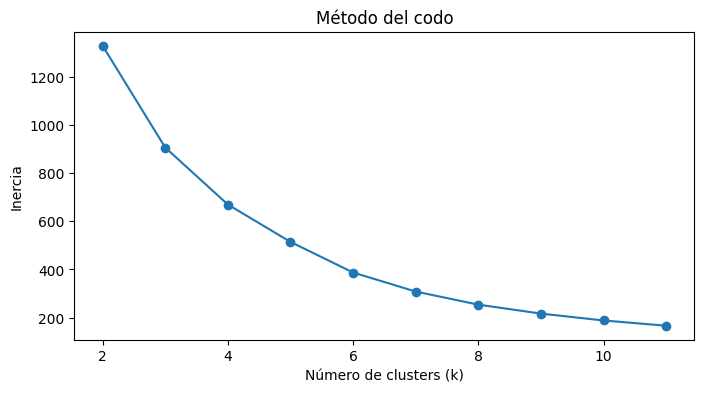

In [19]:
plt.figure(figsize=(8,4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

En el gráfico se observa una caída marcada de la inercia en los primeros valores de `k` y un aplanamiento progresivo a partir de un valor intermedio, lo que sugiere que incrementar `k` más allá de ese punto aporta segmentaciones cada vez más finas pero con menor ganancia en compactación. Por este motivo, la inercia se utiliza como criterio orientativo para acotar un rango razonable de `k`, que luego se complementa con *silhouette score* e inspección visual de los clusters.

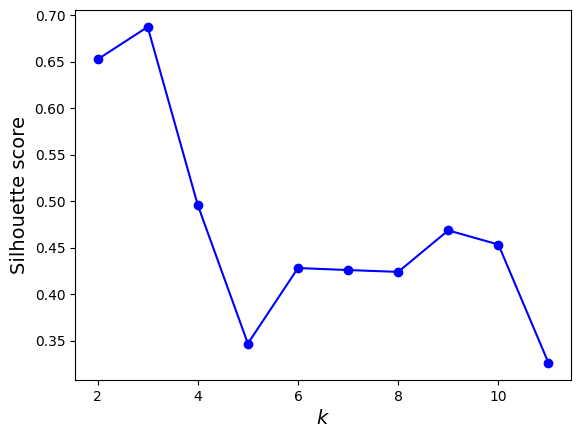

In [20]:
plt.plot(ks, sil_scores, "bo-");
plt.xlabel("$k$", fontsize=14);
plt.ylabel("Silhouette score", fontsize=14)
plt.show()

En el gráfico se observa un valor alto para **k=2–3**, con un **máximo alrededor de k=3**, lo que sugiere que el dataset admite una separación bastante nítida en pocos grupos “grandes”. A partir de **k≥4** el *silhouette* desciende de forma marcada y luego se mantiene en valores moderados, lo que indica que aumentar el número de clusters tiende a generar particiones más finas pero menos claramente separadas. Por este motivo, el *silhouette* se utilizó como criterio complementario al método del codo y a la inspección visual de los clusters para elegir el `k` final.

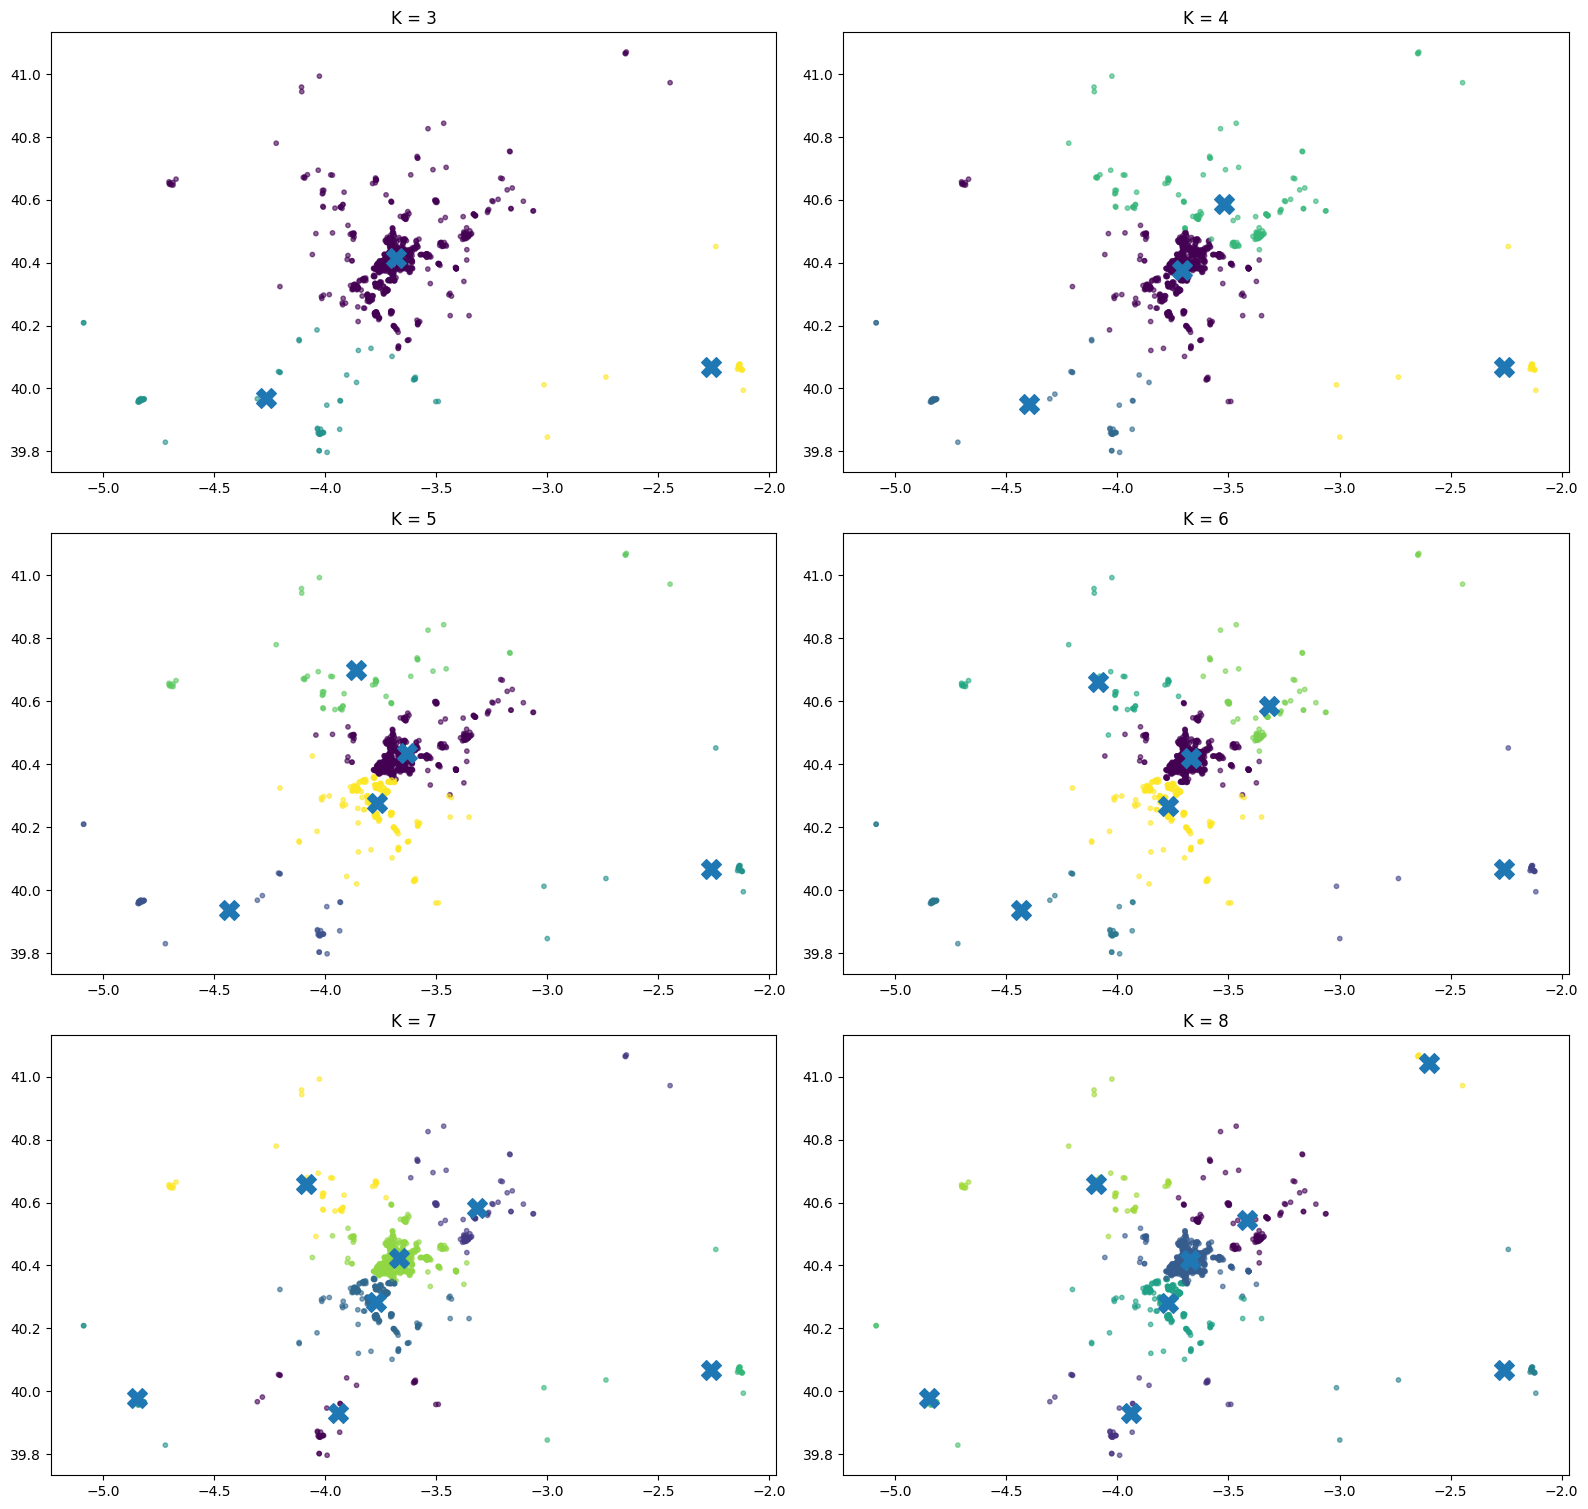

In [21]:
k_values = [3,4,5,6,7,8]

plt.figure(figsize=(16,30))

for i, k in enumerate(k_values):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(coords)
    
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    plt.subplot(6,2,i+1)

    plt.scatter(
        X_train['longitud'],
        X_train['latitud'],
        c=labels,
        s=10,
        alpha=0.6
    )

    plt.scatter(
        centroids[:,1],
        centroids[:,0],
        marker='X',
        s=200
    )

    plt.title(f"K = {k}")

plt.tight_layout()
plt.show()

Como paso final, se visualizaron los clusters geográficos para distintos valores (`k = 3, 4, 5, 6, 7, 8`) y se evaluó la **coherencia espacial** de las particiones. Más allá de las métricas (inercia y *silhouette*), esta inspección permite verificar que los grupos resultantes tengan sentido práctico como aproximación a “zonas” dentro de Madrid.

Integrando (1) los resultados cuantitativos de inercia y *silhouette* y (2) la interpretabilidad de los mapas de clusters apoyada en conocimiento general de la ciudad (zonas y gradientes de coste), se seleccionó **`k = 6`** como configuración final, por ofrecer un equilibrio entre separación razonable y segmentación no excesiva. A partir de esta elección se generó la variable `cluster`, que se incorpora como feature adicional para evaluar su impacto en el modelo supervisado.

In [22]:
k = 6

kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=50)
kmeans_final.fit(coords)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",50
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


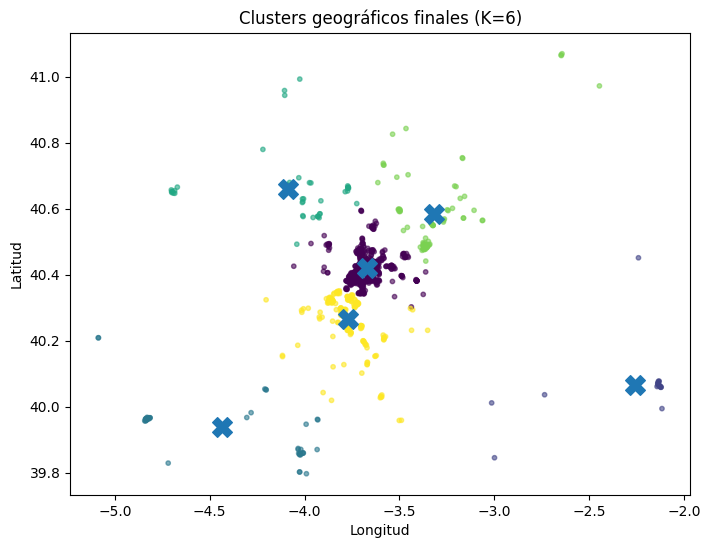

In [23]:
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
clusters = kmeans_final.predict(coords)

plt.figure(figsize=(8,6))

plt.scatter(
    X_train['longitud'],
    X_train['latitud'],
    c=clusters,
    s=10,
    alpha=0.6
)

plt.scatter(
    centroids[:,1],
    centroids[:,0],
    marker='X',
    s=200
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title(f"Clusters geográficos finales (K={k})")
plt.show()

# **Pretratamiento de datos**

In [24]:
cluster_transformer = ColumnTransformer(
    [
        ('cluster', KMeansCluster(n_clusters=6), ['latitud','longitud'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [25]:
drop_step = FunctionTransformer(drop_columns)

In [26]:
pipe_features = Pipeline([
    ('aplanar_campos', FunctionTransformer(aplanar_campos_anidados)),        
    ('poi_features', FunctionTransformer(crear_features_poi)),          
    ('final_clean', FunctionTransformer(limpiar_y_crear_features)),
    ('cluster', cluster_transformer),
    ('drop',drop_step)
])

X_train_limpio = pipe_features.fit_transform(X_train)
X_train_limpio.head()

,latitud,longitud,cluster,dormitorios,superficie_m2,baños,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord,tiene_certificado
1075,40.554002,-3.330893,C,2.0,65.0,1.0,NaN,NO,0,Independiente,1995,0,False,19,262.0,44.0,1,350.0,5,340.0,4,320.0,0,10000.0,3,840.0,1,1300.0,3,600.0,0,10000.0,0,0,0,2.0,True
266,40.327202,-3.854872,F,4.0,90.0,2.0,1.0,NO,0,Independiente,1978,0,False,25,NaN,NaN,5,90.0,5,160.0,5,100.0,5,1500.0,5,270.0,5,390.0,5,460.0,5,400.0,1,0,0,NaN,False
333,40.428702,-3.628553,A,3.0,65.0,1.0,4.0,Independiente,0,centralizada,1960,0,False,8,240.0,45.0,4,120.0,5,70.0,5,250.0,4,560.0,5,300.0,5,690.0,5,510.0,5,300.0,1,0,0,1.0,True
572,40.343602,-3.688422,F,2.0,57.0,1.0,2.0,NO,0,NO,1960,0,False,21,235.0,49.0,5,170.0,5,200.0,5,150.0,0,10000.0,5,530.0,5,650.0,5,650.0,5,460.0,0,0,0,2.0,True
310,40.367602,-3.756012,A,3.0,61.0,1.0,1.0,NO,0,Independiente,1965,1,False,28,NaN,NaN,5,70.0,5,90.0,5,20.0,4,1500.0,5,840.0,5,670.0,5,250.0,5,190.0,1,0,2,NaN,False


# **MiniEDA**

In [27]:
train_set = X_train_limpio.copy()
train_set['Precio'] = y_train.values  
target = 'Precio'

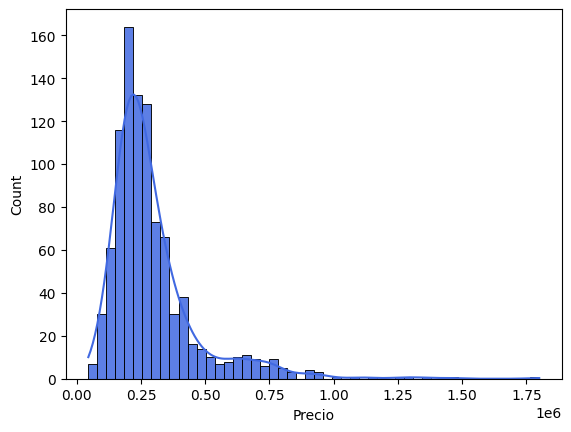

In [28]:
sns.histplot(train_set['Precio'], bins=50, kde=True, color='royalblue', alpha=0.85)
plt.show()

Distribución del precio con cola derecha pronunciada: la mayoría de viviendas se concentra entre ~200k y ~350k, pero hay un grupo pequeño de anuncios muy caros (outliers) que estiran la cola hasta ~2M.

#### **Resumen de `X_train_limpio`**

El set de entrenamiento limpio contiene **968 filas** y **37 columnas**. En general, el dataset está bastante completo: la mayoría de variables no tiene nulos, y los faltantes se concentran principalmente en **`planta` (37.1%)**, **`eficiencia_energetica` (31.5%)**, **`emisiones_energeticas` (31.6%)**, y en menor medida en **`dormitorios` (8.6%)** y **`baños` (8.2%)**.

Para describir y tipificar las features se utilizó un perfilado por **tipo de dato**, **% de nulos** y **cardinalidad** (número de valores distintos). Con ese criterio, las variables con **pocos valores distintos (≤ 10)** se consideran **categóricas** (y si tienen **2 valores**, **binarias**), mientras que el resto se trata como **numéricas**, diferenciando **continuas** cuando la cardinalidad relativa es alta y **discretas** cuando toman pocos valores.

En conjunto, el dataset combina:
- **Ubicación:** `latitud`, `longitud`
- **Características de la vivienda:** `superficie_m2`, `planta`, `dormitorios`, `baños`, `ano_construccion`, etc.
- **Entorno/servicios:** variables de **distancias** y **conteos** a puntos de interés (p. ej., `*_min_dist_m`, `*_cnt`)

In [29]:
X_train_limpio.shape

(968, 37)

In [30]:
describe_df(X_train_limpio).T

Clasificación sugerida para 968 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


Columnas,Tipo_Dato,Nulos,Nulos_%,Cardinalidad,Cardinalidad_%,Clasificacion_sugerida
latitud,float64,0,0.0,827,85.43,Numerica_Continua
longitud,float64,0,0.0,949,98.04,Numerica_Continua
cluster,str,0,0.0,6,0.62,Categorica
dormitorios,float64,83,8.6,6,0.62,Categorica
superficie_m2,float64,0,0.0,161,16.63,Numerica_Continua
baños,float64,79,8.2,4,0.41,Categorica
planta,float64,359,37.1,13,1.34,Numerica_Discreta
aire_acondicionado,str,0,0.0,3,0.31,Categorica
ascensor,int64,0,0.0,2,0.21,Categorica_Binaria
calefaccion,str,0,0.0,3,0.31,Categorica


## **Analisis bivariante**

### Target contra variables **categóricas, ordinales y binarias**

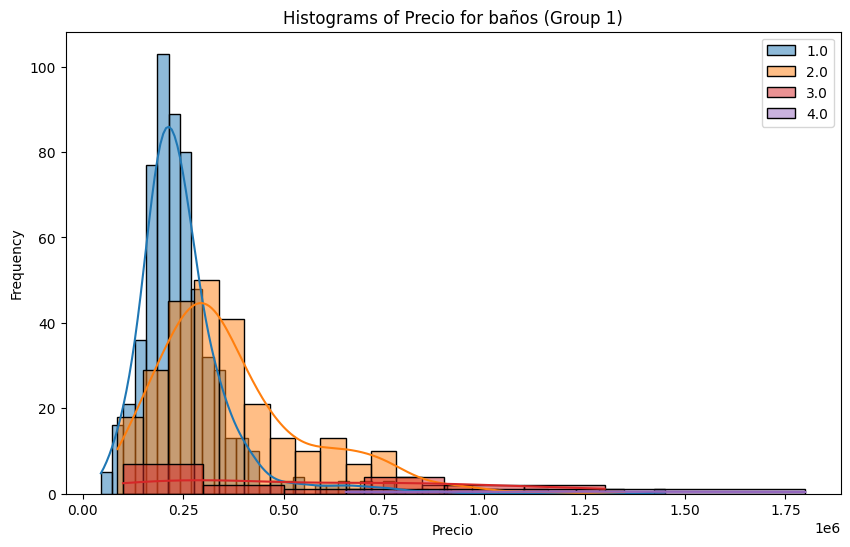

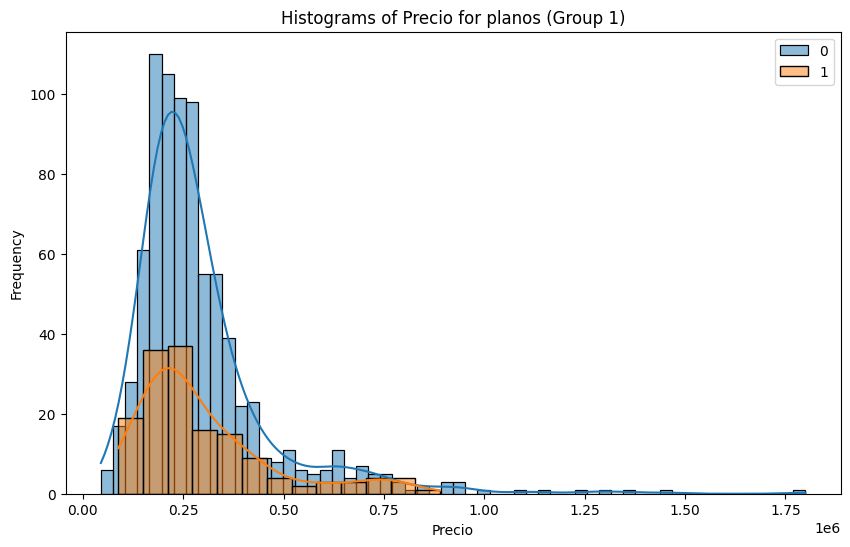

In [31]:
for col in ['baños','planos']:
     bt.plot_grouped_histograms(train_set, cat_col=col, num_col='Precio', group_size = 8)

En esta etapa se realizó una selección visual inicial de *features* comparando la distribución del **precio (target)** frente a variables **categóricas, ordinales y binarias**, utilizando **histogramas y curvas de densidad por categoría**. El criterio aplicado fue uniforme: se consideró que una variable aporta información cuando, al estratificar por categorías, las distribuciones del precio muestran **desplazamientos** (corrimiento hacia valores mayores/menores), **separación parcial** o **cambios de forma** (por ejemplo, colas/outliers concentrados en determinadas categorías). En cambio, cuando las curvas quedan **muy solapadas** y mantienen formas similares entre grupos, se interpretó como una señal débil y, por tanto, menor interés para el modelo en esta fase exploratoria (a confirmar posteriormente mediante validación y comparación de métricas).

Para ejemplificar este criterio, en el informe se incluyen dos figuras. En primer lugar, se presenta **baños** como ejemplo de **alto interés**: al aumentar la categoría, la distribución del precio tiende a **desplazarse hacia la derecha**, con un gradiente especialmente evidente entre categorías bajas (p. ej., 1→2), lo que sugiere una relación estructural consistente con el target y potencial capacidad discriminante. En contraste, se incluye **planos** como ejemplo de **bajo interés**: las distribuciones para 0/1 permanecen **marcadamente superpuestas**, con picos y colas similares y sin un desplazamiento sistemático del precio entre categorías, por lo que se consideró una variable candidata a simplificación si su inclusión no aporta mejora en el rendimiento del modelo.

Con base en esta inspección visual, se estableció una clasificación operativa de variables por nivel de interés. Se consideraron de **`alto interés`**: **baños**, **dormitorios**, **categoria_ord** y **ascensor**. Se clasificaron como de **`interés moderado`**: **calefacción**, **clase_energetica_ord**, **transporte_publico**, **hospitales** y el **cluster geográfico (K-Means)**, al observarse tendencias parciales o indicios plausibles pero con solapamiento relevante, desbalance entre categorías o posible captura indirecta de **zona/centralidad**. Finalmente, se catalogaron como de **`bajo interés`** (candidatas a simplificación): **aire_acondicionado**, **planos**, **tiene_certificado**, **realista**, las banderas específicas de **tipo de calefacción (gas/eléctrica)** y el **resto de POIs** (p. ej., escuelas, farmacias, supermercados, tiendas, restaurantes, bares), dado el solapamiento marcado y/o la dominancia de una categoría. Esta clasificación se utilizará como referencia para contrastar posteriormente si las variables descartadas por no mejorar la métrica del modelo coinciden con las identificadas visualmente como de bajo interés.

### Target contra variables **numéricas**

In [32]:
num_discreta = tipifica_variables(X_train_limpio)['Numerica_Discreta']
num_continua = tipifica_variables(X_train_limpio)['Numerica_Continua']
numericas = num_discreta + num_continua
numericas_con_precio = numericas + ['Precio']

In [33]:
print('Correlacion de spearman:')
corr_spe = train_set[numericas_con_precio].corr('spearman')
np.abs(corr_spe[target]).sort_values(ascending = False)

Correlacion de spearman:


Precio                   1.000000
superficie_m2            0.396420
latitud                  0.366141
resto_min_dist_m         0.238357
tp_min_dist_m            0.212868
fotografias              0.209886
planta                   0.196219
fca_min_dist_m           0.193200
hosp_min_dist_m          0.189559
emisiones_energeticas    0.172468
tda_min_dist_m           0.161483
bar_min_dist_m           0.133655
super_min_dist_m         0.128357
eficiencia_energetica    0.104518
esc_min_dist_m           0.102097
longitud                 0.056656
ano_construccion         0.024920
Name: Precio, dtype: float64

#### **Matriz de correlacion**

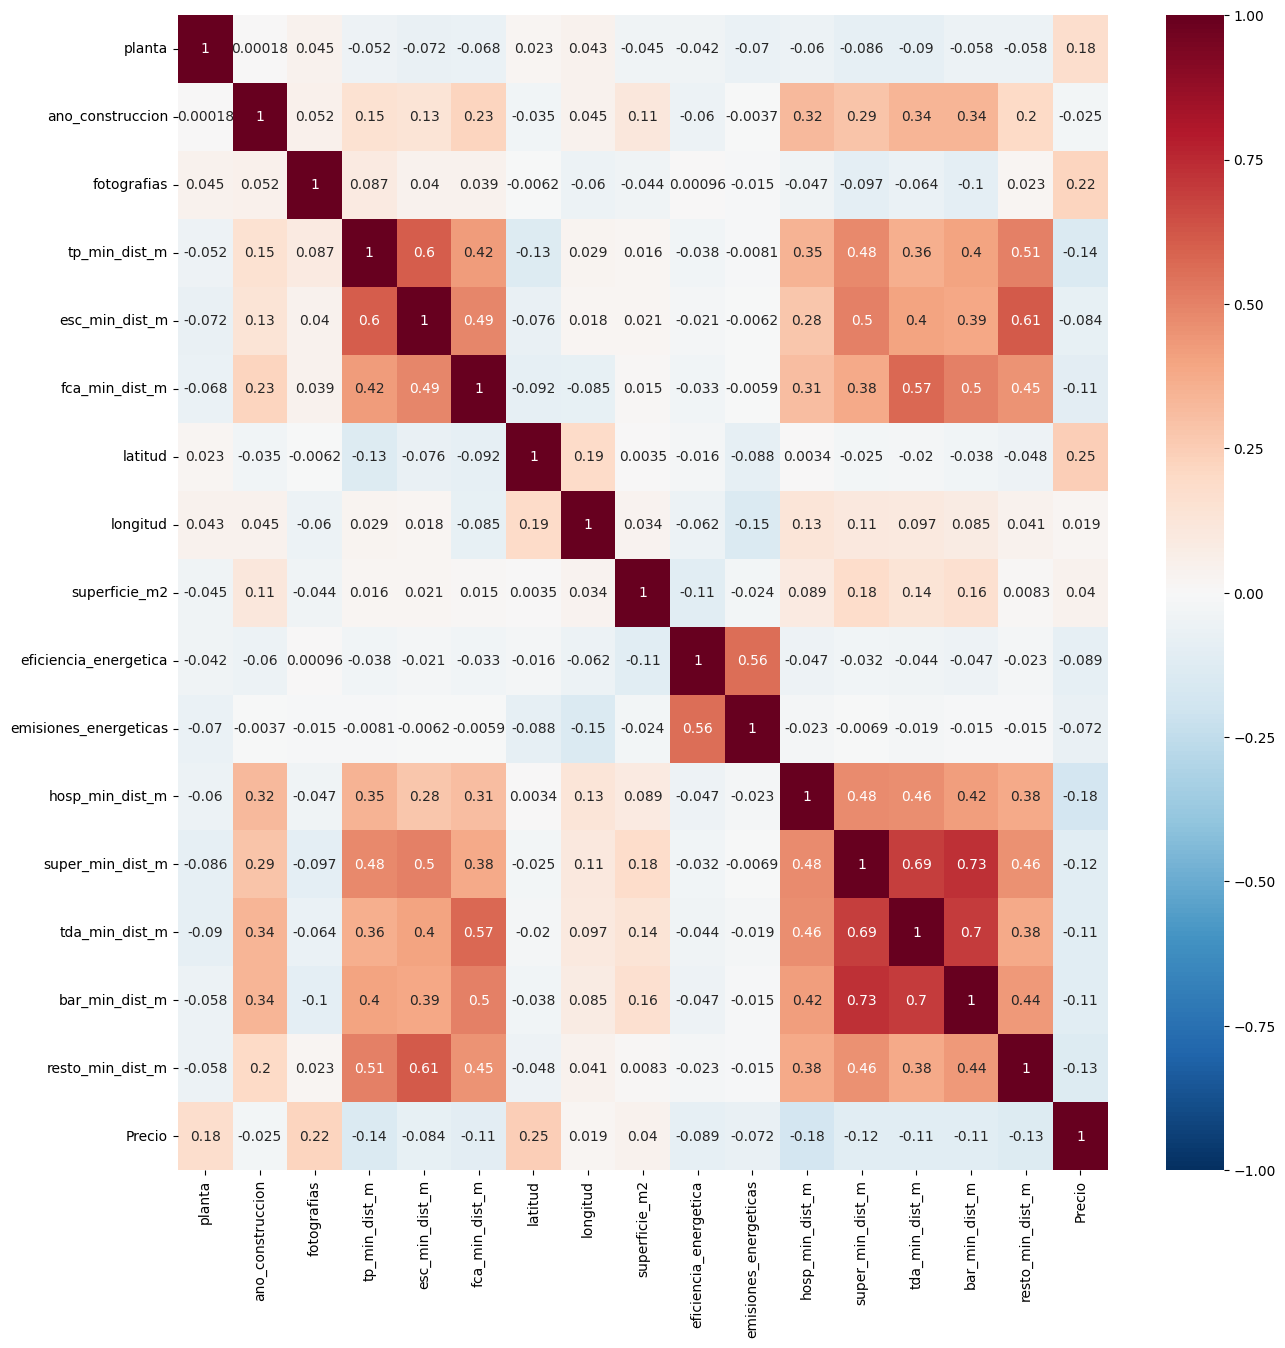

In [34]:
corr = train_set[numericas_con_precio].corr('pearson')
plt.figure(figsize = (15,15))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.show()

Para una primera exploración cuantitativa de la relación entre el **precio (target)** y las variables **numéricas**, se calcularon correlaciones bivariantes (Pearson y Spearman) como filtro orientativo. Estas correlaciones no deben interpretarse como “importancia” definitiva, ya que en datos inmobiliarios son habituales la **asimetría del target**, la presencia de **outliers** y relaciones **no lineales** o con **interacciones** (por ejemplo, zona × superficie). Por este motivo, se priorizó **Spearman** como referencia principal (más robusta ante outliers y capaz de capturar asociaciones monótonas aunque no sean lineales), usando Pearson como complemento para contrastar linealidad.

Tras el análisis bivariante, se calculó y se presenta la **matriz de correlación entre variables numéricas** para entender cómo se relacionan entre sí los predictores y detectar **colinealidad**. El objetivo de esta matriz no es “explicar el precio”, sino identificar variables que aportan información muy similar (redundancia). En la matriz se observa que las correlaciones más altas se concentran entre varias variables de **distancias mínimas a puntos de interés (POIs)**, lo cual es esperable: zonas con mayor densidad de servicios suelen tener múltiples POIs cercanos simultáneamente, por lo que estas variables tienden a capturar un factor común asociado a **entorno/centralidad**. En esta etapa no se descarta ninguna variable únicamente por correlación entre predictores, ya que los modelos basados en árboles/boosting suelen tolerar mejor la colinealidad; sin embargo, esta matriz se conserva como referencia para interpretar resultados y para una posible simplificación posterior si se detecta redundancia sin ganancia predictiva.

Con base en el análisis de correlación (priorizando Spearman por robustez ante asimetría y outliers) y la revisión de colinealidad en la matriz de correlación, se estableció una clasificación operativa de variables numéricas por nivel de interés. Se consideraron de **`alto interés`**: **superficie_m2** y **latitud**, por presentar la señal más consistente frente al target. Se clasificaron como de **`interés moderado`**: **fotografias**, **planta**, **eficiencia_energetica** y las variables de distancias mínimas a POIs (**resto_min_dist_m**, **tp_min_dist_m**, **hosp_min_dist_m**, **fca_min_dist_m**, **tda_min_dist_m**, **super_min_dist_m**, **bar_min_dist_m**, **esc_min_dist_m**), al mostrar asociación con el precio pero con posible redundancia entre sí (colinealidad) al capturar en parte un mismo factor de entorno/centralidad. Finalmente, se catalogaron como de **`bajo interés`**: **emisiones_energeticas**, **longitud** y **ano_construccion**, al presentar correlación bivariante débil con el target en este dataset. Esta clasificación se utilizará como referencia para contrastar posteriormente si las variables descartadas por no mejorar la métrica del modelo coinciden con las identificadas inicialmente como de bajo interés.

### **Transformación logarítmica del target**

El **precio** presenta una distribución con **cola derecha** y **outliers**, por lo que se aplicó una transformación logarítmica al target (**Precio_log**) antes del entrenamiento. Esto reduce la influencia de valores extremos, estabiliza la varianza y suele modelar mejor relaciones **multiplicativas** (cambios relativos de precio) frecuentes en problemas inmobiliarios.

En el modelo final se entrenó sobre `Precio_log` y, para reportar resultados en euros, las predicciones se revirtieron con la transformación inversa. Este paso busca mejorar estabilidad/robustez del entrenamiento; la selección de variables y el rendimiento final se confirman con validación del modelo.

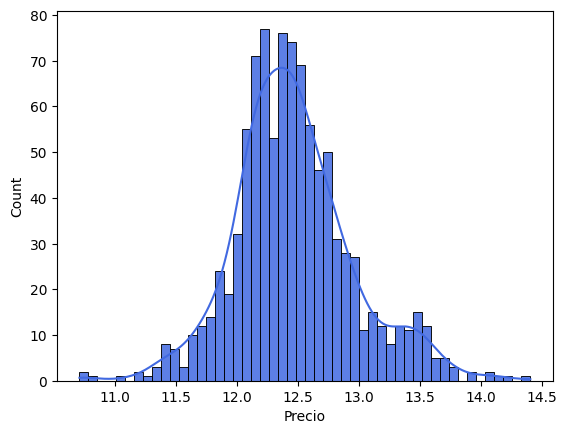

In [29]:
sns.histplot(np.log(train_set['Precio']), bins=50, kde=True, color='royalblue', alpha=0.85)
plt.show()

# **Comparación inicial de modelos**  

Con el dataset ya preparado, se realizó una primera comparación de modelos para tener un **baseline** y elegir una familia de algoritmos para la etapa de ajuste fino. Para que la comparación sea justa y reproducible, se armó un flujo con `Pipeline` + `ColumnTransformer`, separando el tratamiento de variables numéricas y categóricas:

- **Numéricas:** imputación por mediana.  
- **Categóricas:** imputación por moda + `OneHotEncoder`.

Se implementaron **dos preprocesados**:
1) Un preprocesado **sin escalado**, pensado para modelos basados en árboles/boosting (no requieren estandarización).
2) Un preprocesado **con escalado** (`StandardScaler`), necesario para modelos sensibles a la escala como **KNN** y **regresión lineal**.

Además, para estabilizar el entrenamiento frente al sesgo del target, se evaluaron los modelos usando una transformación del target (log) mediante `TransformedTargetRegressor`, manteniendo la comparación consistente entre algoritmos.

Los modelos comparados fueron:
- **Árboles y ensembles:** `DecisionTreeRegressor`, `RandomForestRegressor`
- **Boosting:** `XGBRegressor`, `LGBMRegressor`, `CatBoostRegressor`
- **Modelos basados en distancia / lineales (con escalado):** `KNeighborsRegressor` (k=3 y k=5) y `LinearRegression`

Dado lo observado en el EDA (relaciones no lineales, interacción entre variables y presencia de outliers), se espera que los modelos de **árboles/boosting** tengan mejor desempeño que un enfoque estrictamente lineal. Aun así, se incluyen modelos lineales y KNN como referencia comparativa.

#### **Métrica de evaluación: MAPE**

Para comparar modelos se utilizó **MAPE** (*Mean Absolute Percentage Error*). Elegimos esta métrica porque mide el error en **términos relativos** (porcentaje), lo que resulta más apropiado en precios inmobiliarios donde el target tiene **cola derecha y outliers**: un error absoluto grande en euros puede ser esperable en viviendas muy caras, pero no necesariamente representa el mismo “nivel de fallo” que ese mismo error en una vivienda media. 

En otras palabras, MAPE penaliza el error de manera proporcional al valor real del inmueble, lo que hace la comparación más estable cuando hay anuncios de precios muy altos. Por eso es una métrica útil para tener una primera foto del desempeño de los modelos en un dataset con alta dispersión y valores extremos.

In [35]:
num_sel = make_column_selector(dtype_include = np.number)
cat_sel = make_column_selector(dtype_include = object)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            ]), num_sel),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),
    ],
    remainder='drop',
).set_output(transform='pandas')

preprocess_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_sel),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),
    ],
    remainder='drop'
).set_output(transform='pandas')

In [36]:
models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest': RandomForestRegressor(max_depth=5, random_state=42),
    'XGBRegressor': XGBRegressor(max_depth=5, random_state=42, objective='reg:absoluteerror',),
    'LGBMRegressor': LGBMRegressor(max_depth=5, random_state=42, verbosity=-1),
    'CatBoostRegressor': CatBoostRegressor(depth=5, random_state=42, loss_function='MAPE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando XGBRegressor...
Entrenando LGBMRegressor...
Entrenando CatBoostRegressor...


In [37]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess_scale), ('model', model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores_scale = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_MAPE')
results_df

Entrenando lr_reg...
Entrenando knn_reg_3...
Entrenando knn_reg_5...


,model,mean_MAPE
4,CatBoostRegressor,1.677783e-01
3,LGBMRegressor,1.749519e-01
2,XGBRegressor,1.867364e-01
1,RandomForest,2.075798e-01
0,DecisionTree,2.541529e-01
7,knn_reg_5,2.657561e-01
6,knn_reg_3,2.782526e-01
5,lr_reg,1.565423e+24


En esta primera corrida, los modelos con mejor desempeño fueron los de **boosting**, destacándose de forma consistente **LightGBM**, **CatBoost** y **XGBoost** como el top 3. En un segundo escalón quedaron **RandomForest** y **DecisionTree**, mientras que **KNN** rindió peor que los boosting. La **regresión lineal** no resultó competitiva en este problema, lo cual es coherente con lo observado en el EDA: hay no linealidades, interacción entre variables y efectos de zona que un modelo lineal no captura bien.

### **Ajuste de hiperparametros**

Una vez identificados los modelos con mejor desempeño en la comparación inicial, pasamos a una etapa de **ajuste de hiperparámetros** para intentar mejorar el rendimiento. Para esto se utiliza **Optuna**, que permite explorar de forma automática y eficiente distintas combinaciones de parámetros y seleccionar las que optimizan la métrica elegida.

En esta sección se ajustarán los tres modelos top: **XGBoost**, **LightGBM** y **CatBoost**, manteniendo el mismo esquema de validación y la misma métrica (MAPE) para que los resultados sean comparables.

In [38]:
objective_xgb = make_objective_xgb(X_train_limpio, y_train, preprocess, cv=5)

study_xgb = create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=5)

best_params_xgb = study_xgb.best_params
best_params_xgb

[I 2026-03-03 22:34:02,451] A new study created in memory with name: no-name-40edddf7-33ed-45fb-b67a-0b9e9685ffc4
[I 2026-03-03 22:34:03,318] Trial 0 finished with value: -0.16870582699775696 and parameters: {'model__n_estimators': 884, 'model__learning_rate': 0.03901484010257789, 'model__max_depth': 4, 'model__min_child_weight': 2, 'model__subsample': 0.7429495767745239, 'model__colsample_bytree': 0.9362126559104494, 'model__reg_alpha': 0.20023381318374542, 'model__reg_lambda': 2.5974127745017634}. Best is trial 0 with value: -0.16870582699775696.
[I 2026-03-03 22:34:05,465] Trial 1 finished with value: -0.16816528141498566 and parameters: {'model__n_estimators': 755, 'model__learning_rate': 0.01807687723471877, 'model__max_depth': 8, 'model__min_child_weight': 1, 'model__subsample': 0.792351063660268, 'model__colsample_bytree': 0.780815592177342, 'model__reg_alpha': 0.006114006181160928, 'model__reg_lambda': 1.4268945976498202}. Best is trial 1 with value: -0.16816528141498566.
[I 20

{'model__n_estimators': 755,
 'model__learning_rate': 0.01807687723471877,
 'model__max_depth': 8,
 'model__min_child_weight': 1,
 'model__subsample': 0.792351063660268,
 'model__colsample_bytree': 0.780815592177342,
 'model__reg_alpha': 0.006114006181160928,
 'model__reg_lambda': 1.4268945976498202}

In [39]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

pipe_xgb_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...00164273BB740>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity fu

In [40]:
print(f' MAPE XGBoost: {mean_absolute_percentage_error(y_test, pipe_xgb_log.predict(X_test))}')

 MAPE XGBoost: 0.15051445364952087


In [43]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

modelo_final = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

modelo_final.fit(X, y)

dump(modelo_final, './src./models/modelo_final.joblib', compress=3)

['./src./models/modelo_final.joblib']

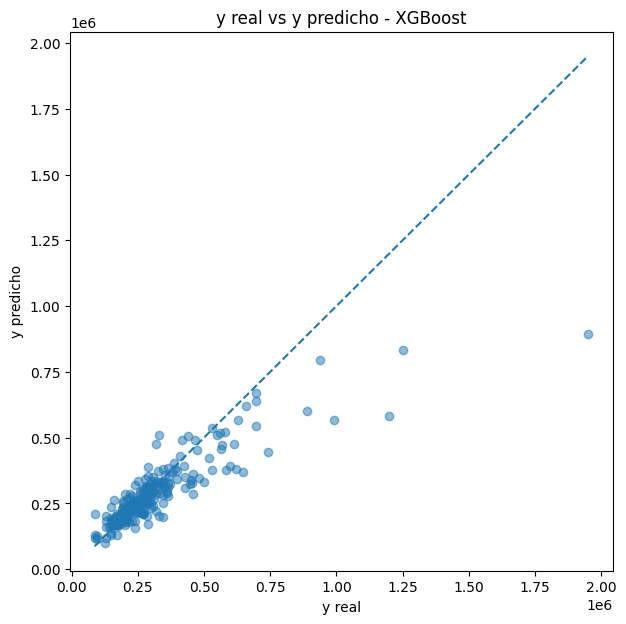

In [44]:
y_pred_xgb = pipe_xgb_log.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
min_v = min(np.min(y_test), np.min(y_pred_xgb))
max_v = max(np.max(y_test), np.max(y_pred_xgb))
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')  # línea y=x (predicción perfecta)
plt.xlabel('y real')
plt.ylabel('y predicho')
plt.title('y real vs y predicho - XGBoost')
plt.show()

In [45]:
objective_lgb = make_objective_lgb(X_train_limpio, y_train, preprocess, cv=5)

study_lgb = create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=5)

best_params_lgb = study_lgb.best_params
best_params_lgb

[I 2026-03-03 22:35:31,022] A new study created in memory with name: no-name-f72f462c-eb9a-44dd-bda6-4bbf8b582890
[I 2026-03-03 22:35:32,649] Trial 0 finished with value: -0.1863356565518001 and parameters: {'model__n_estimators': 1049, 'model__learning_rate': 0.149517544924549, 'model__max_depth': 12, 'model__num_leaves': 66, 'model__min_child_samples': 46, 'model__subsample': 0.7047110791991611, 'model__colsample_bytree': 0.7969465936377074, 'model__reg_alpha': 0.007901905733408845, 'model__reg_lambda': 2.088959330860999}. Best is trial 0 with value: -0.1863356565518001.
[I 2026-03-03 22:35:34,232] Trial 1 finished with value: -0.17914706353678655 and parameters: {'model__n_estimators': 1025, 'model__learning_rate': 0.09559761640392814, 'model__max_depth': 9, 'model__num_leaves': 53, 'model__min_child_samples': 42, 'model__subsample': 0.8629469813198494, 'model__colsample_bytree': 0.7714325307899551, 'model__reg_alpha': 0.09412121232082875, 'model__reg_lambda': 3.6239625899566503}. B

{'model__n_estimators': 810,
 'model__learning_rate': 0.08458318437245425,
 'model__max_depth': 12,
 'model__num_leaves': 20,
 'model__min_child_samples': 17,
 'model__subsample': 0.8238339973811464,
 'model__colsample_bytree': 0.9123838433415266,
 'model__reg_alpha': 0.07599408070120418,
 'model__reg_lambda': 4.838089232615547}

In [46]:
lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
pipe_lgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', lgb_base)])

pipe_lgb.set_params(**best_params_lgb)

pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)

pipe_lgb_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...rbosity=-1))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...00164273BB740>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity func

In [47]:
print(f' MAPE LGBoost: {mean_absolute_percentage_error(y_test, pipe_lgb_log.predict(X_test))}')

 MAPE LGBoost: 0.15445154223220697


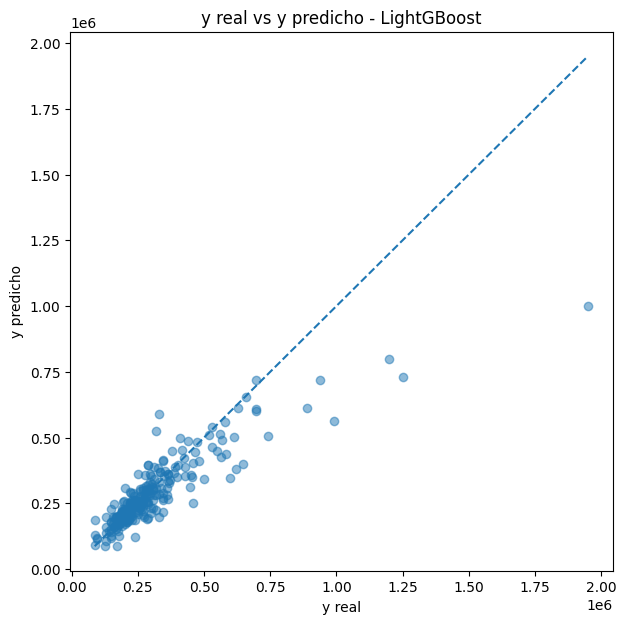

In [48]:
y_pred_lgb = pipe_lgb_log.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_lgb, alpha=0.5)
min_v = min(np.min(y_test), np.min(y_pred_lgb))
max_v = max(np.max(y_test), np.max(y_pred_lgb))
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')  # línea y=x (predicción perfecta)
plt.xlabel('y real')
plt.ylabel('y predicho')
plt.title('y real vs y predicho - LightGBoost')
plt.show()

In [50]:
objective_cat = make_objective_cat(X_train_limpio, y_train, preprocess, cv=5)

study_cat = create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=5)

best_params_cat = study_cat.best_params
best_params_cat

[I 2026-03-03 22:35:50,812] A new study created in memory with name: no-name-78a5fcea-d208-40f9-b478-04e2c4cdffdd
[I 2026-03-03 22:35:55,191] Trial 0 finished with value: -0.1892861549035089 and parameters: {'model__depth': 6, 'model__learning_rate': 0.0101200305204286, 'model__iterations': 606, 'model__l2_leaf_reg': 5.821528213373687, 'model__subsample': 0.964803811633824, 'model__random_strength': 1.8229860594421334}. Best is trial 0 with value: -0.1892861549035089.
[I 2026-03-03 22:36:02,569] Trial 1 finished with value: -0.1825655333360813 and parameters: {'model__depth': 8, 'model__learning_rate': 0.01677619611789537, 'model__iterations': 624, 'model__l2_leaf_reg': 2.078995268279037, 'model__subsample': 0.730615727817554, 'model__random_strength': 1.1342459152776416}. Best is trial 1 with value: -0.1825655333360813.
[I 2026-03-03 22:36:06,349] Trial 2 finished with value: -0.18954809199822828 and parameters: {'model__depth': 7, 'model__learning_rate': 0.010563311366522424, 'model_

{'model__depth': 7,
 'model__learning_rate': 0.1245075793422897,
 'model__iterations': 833,
 'model__l2_leaf_reg': 2.920670940828359,
 'model__subsample': 0.8858504668416042,
 'model__random_strength': 0.977265350427535}

In [53]:
cat_base = CatBoostRegressor(random_state=42, loss_function='MAPE', verbose=False)
pipe_cat = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', cat_base)])

pipe_cat.set_params(**best_params_cat)

pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)

pipe_cat_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...bose=False))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...00164273BB740>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity func

In [54]:
print(f' MAPE CatBoost: {mean_absolute_percentage_error(y_test, pipe_cat_log.predict(X_test))}');

 MAPE CatBoost: 0.16924000609501763


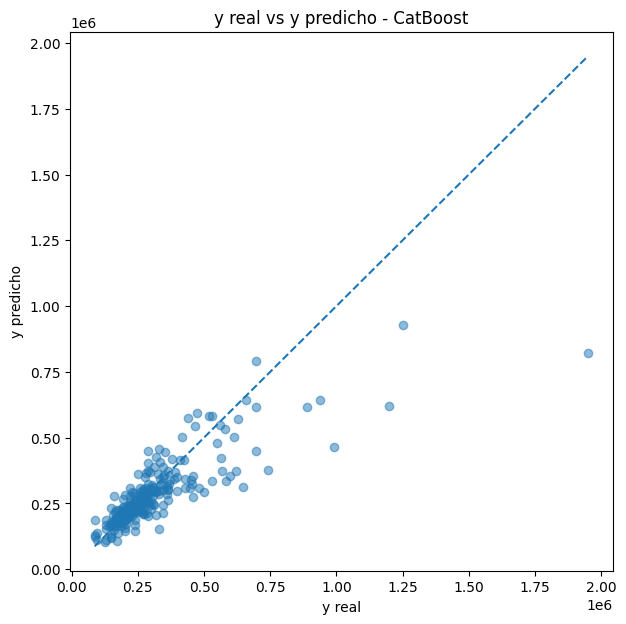

In [55]:
y_pred_cat = pipe_cat_log.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_cat, alpha=0.5)
min_v = min(np.min(y_test), np.min(y_pred_cat))
max_v = max(np.max(y_test), np.max(y_pred_cat))
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')  # línea y=x (predicción perfecta)
plt.xlabel('y real')
plt.ylabel('y predicho')
plt.title('y real vs y predicho - CatBoost')
plt.show()

### **Comparación final entre los 3 mejores modelos (error, gráfico y tiempo)**

Para decidir el modelo final, además del MAPE se revisó el gráfico **`y_real vs y_predicho`** y el **tiempo de entrenamiento/predicción** de cada alternativa (XGBoost, LightGBM y CatBoost). En los tres scatter plots, la mayoría de puntos se concentra cerca de la diagonal (predicción perfecta), pero se ve el patrón típico del problema: a medida que sube el precio real, aparece más dispersión y algunos outliers quedan subestimados o sobreestimados.

En términos de **error**, XGBoost fue el que obtuvo el mejor MAPE (menor valor), mientras que LightGBM y CatBoost quedaron ligeramente por encima. En cuanto a **comportamiento visual**, XGBoost muestra una nube de puntos más “apretada” alrededor de la diagonal en el rango donde se concentra la mayor parte del dataset, y las mayores discrepancias aparecen principalmente en los precios más altos (outliers), que es esperable dado el sesgo del target.

Finalmente, al considerar el **tiempo**, CatBoost resultó claramente el más lento, LightGBM quedó en un punto intermedio y XGBoost fue el más rápido de los tres en esta corrida. 

Con estos tres elementos en conjunto (**mejor MAPE + buena alineación visual + menor tiempo**), se elige **XGBoost** como modelo final para continuar con el ajuste de hiperparámetros y la evaluación definitiva. Primero haremos un estudio de rendimiento para obtener un modelo más ligero con una seleccion de features inteligente:

In [56]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

start = time()
pipe_xgb_log.fit(X_train_limpio, y_train)
train_time = [(time() - start)]

score = [cross_val_score(pipe_xgb_log, X_train_limpio, y_train, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean()]

pd.DataFrame({'score': score, 'time': train_time}).sort_values('score')

,score,time
0,-0.168165,1.062279


### **Eliminación de *features* (selección final basada en rendimiento)**

Antes de entrenar el modelo final, definimos como punto de partida el algoritmo ganador del benchmark previo (el que mostró mejor equilibrio entre métrica y tiempo). A partir de ese modelo “base”, el objetivo de este bloque es estimar **qué variables realmente aportan valor predictivo** cuando el modelo aprende con todas las *features* en conjunto, y no solo en análisis bivariantes.

Para ello, implementamos una función de **eliminación iterativa de features**: en cada iteración se elimina **una variable**, se reentrena el modelo y se registra (1) la **métrica de desempeño** y (2) el **tiempo de entrenamiento/inferencia**. La lógica es identificar cuáles variables tienen **bajo aporte marginal**: si al quitarlas la métrica **se mantiene** (o incluso mejora levemente por reducción de ruido/colinealidad), esa variable se considera prescindible en ese punto del pipeline. En paralelo, medir el tiempo permite evaluar el **costo computacional** de mantener un conjunto grande de variables: si se logra un desempeño similar con menos *features* y menor tiempo, el modelo resultante es más eficiente y más fácil de mantener.

En resumen, este procedimiento nos permite responder dos preguntas prácticas: (1) **cuántas variables pueden eliminarse** sin degradar el rendimiento del modelo y (2) **qué ganancia en tiempo** (coste computacional) se obtiene al simplificar el set de *features*. Luego, a partir del gráfico/tabla de resultados, se extrae una conclusión sobre qué variables se eliminaron primero, cuáles se mantuvieron hasta el final y cómo se relaciona esto con la selección visual/correlacional realizada en el EDA.

In [57]:
def performar_tiempo(X, y, col=None):

    if col:
        X = X.drop(columns=col)

    lista_col = []
    train_time = []
    score = []

    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])
    pipe_xgb.set_params(**best_params_xgb)
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

    for col in X.columns:

        print(f'Ocultando {col}...', end='\t')
        lista_col.append(col)
        X_menos = X.drop(columns=col)

        start = time()
        pipe_xgb_log.fit(X_menos, y)
        train_time.append(time() - start)

        score.append(cross_val_score(pipe_xgb_log, X_menos, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean())
    
    resultados = pd.DataFrame({'columna': lista_col, 'score': score, 'time': train_time}).set_index('columna').sort_values('score', ascending=False).iloc[0]

    if len(X.columns) > 2:
        print(f'Eliminamos {resultados.name}...')
        resultados = pd.concat([resultados, performar_tiempo(X, y, col=resultados.name)], axis=1)

    return resultados

resultados_funcion = performar_tiempo(X_train_limpio, y_train)
resultados_funcion

Ocultando latitud...	Ocultando longitud...	Ocultando cluster...	Ocultando dormitorios...	Ocultando superficie_m2...	Ocultando baños...	Ocultando planta...	

KeyboardInterrupt: 

In [ ]:
resultados_funcion.T.reset_index().reset_index()


,level_0,index,score,time
0,0,emisiones_energeticas,-0.162590,0.758061
1,1,tiene_certificado,-0.162590,0.757280
2,2,realista,-0.162590,0.793649
3,3,fotografias,-0.163399,0.757717
4,4,resto_cnt,-0.162648,0.762101
5,5,aire_acondicionado,-0.162701,0.810068
6,6,tda_min_dist_m,-0.162686,0.757261
7,7,tp_cnt,-0.160759,0.720571
8,8,bar_cnt,-0.162024,0.732436
9,9,super_min_dist_m,-0.162100,0.710808


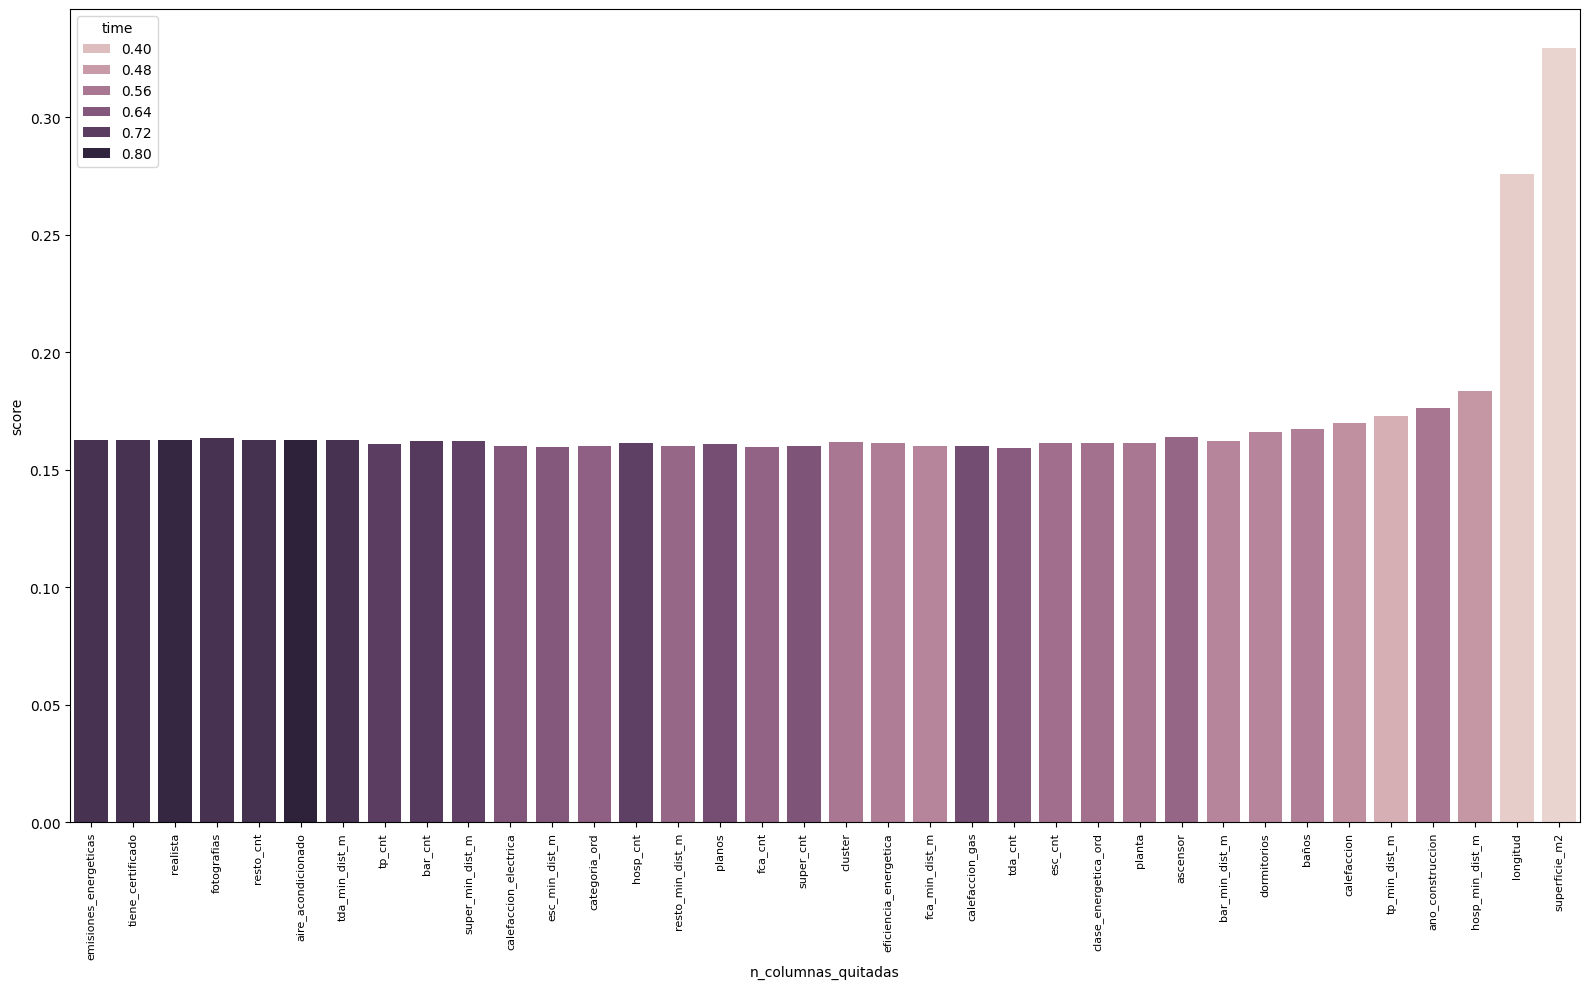

In [ ]:
res = resultados_funcion.T.reset_index().reset_index()

res['score'] = res['score'] * -1
res['level_0'] = res['level_0'] + 1

res = res.rename(columns={'level_0': 'n_columnas_quitadas'})

# res['level_0_bin'] = pd.cut(res['level_0'], bins=3)

# sns.barplot(res, x='n_columnas_quitadas', y='score', hue='time')

plt.figure(figsize=(16, 10))
ax = sns.barplot(res, x='n_columnas_quitadas', y='score', hue='time')

ax.set_xticks(range(len(res)))
ax.set_xticklabels(res['index'], rotation=90)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()

Los primeros descartes —**emisiones_energeticas**, **tiene_certificado** y **realista**— son coherentes con lo observado en el EDA: **realista** ya se había catalogado como **bajo interés** por fuerte solapamiento en los histogramas, y **tiene_certificado** mostró distribuciones muy superpuestas (reclasificada también como **bajo interés**). En el caso de **emisiones_energeticas**, su eliminación temprana se interpreta principalmente como efecto de **redundancia**: presenta correlación moderada con **eficiencia_energetica** (≈0.52) y, además, su relación con el target es más débil, por lo que resulta razonable priorizar **eficiencia_energetica** (mantenida como **interés moderado**) y relegar **emisiones_energeticas** a **bajo interés**.

A medida que avanzan las iteraciones, también aparecen entre las variables prescindibles algunas relacionadas con **entorno/POIs** (p. ej., contadores o distancias), lo cual es consistente con la **colinealidad** detectada en la matriz de correlación: muchas de estas variables capturan parcialmente el mismo factor latente de **centralidad/entorno**, por lo que el modelo puede mantener desempeño con un subconjunto reducido de ellas. En contraste, las *features* que tienden a sostener el rendimiento hasta etapas finales —como **superficie_m2** y variables estructurales (p. ej., **baños**, **dormitorios**)— reflejan señales más estables y directas sobre el precio.

En síntesis, la eliminación por rendimiento confirmó parte de las hipótesis del análisis visual/correlacional (identificando como prescindibles variables inicialmente débiles) y, al mismo tiempo, mostró que algunas variables con señal moderada en análisis bivariante pueden no aportar valor incremental cuando existen **proxies redundantes** o el modelo ya captura esa información por otras vías.

In [ ]:
columnas_a_quitar = resultados_funcion.T[:36].index.to_list()

X_train_opt = X_train_limpio.drop(columns=columnas_a_quitar)

X_train_opt

,latitud
788,40.377002
665,40.446802
296,40.489802
567,40.421302
679,40.646702
...,...
1044,40.481702
1095,40.478202
1130,39.859802
860,40.317202


In [ ]:
def objective_xgb(trial):
    
    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 8),
        'model__min_child_weight': trial.suggest_int('model__min_child_weight', 1, 5),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_xgb.set_params(**params)
    
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_xgb_log,
        X_train_opt,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_xgb = create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

best_params_xgb = study_xgb.best_params
best_params_xgb

[I 2026-03-01 20:10:58,805] A new study created in memory with name: no-name-32992e56-1a60-4a94-95a9-ff84efcd4bf3
[W 2026-03-01 20:10:58,807] Trial 0 failed with parameters: {'model__n_estimators': 1003, 'model__learning_rate': 0.03333903186696641, 'model__max_depth': 8, 'model__min_child_weight': 2, 'model__subsample': 0.7807081090524508, 'model__colsample_bytree': 0.8626760142605077, 'model__reg_alpha': 0.3660722014387644, 'model__reg_lambda': 4.444020594067062} because of the following error: NameError("name 'X_train_opt' is not defined").
Traceback (most recent call last):
  File "c:\Users\phbas\Documents\Bootcamp_Data_Science\ML_Prediccion_Precio_Vivienda_Madrid\venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\phbas\AppData\Local\Temp\ipykernel_19932\758723064.py", line 23, in objective_xgb
    X_train_opt,
    ^^^^^^^^^^^
NameError: name 'X_train_opt' is not defined
[W 2

NameError: name 'X_train_opt' is not defined

26 -> 0.1590

27 -> 0.1600

28 -> 0.1584

29 -> 0.1693

30 -> 0.1648

31 -> 0.1674

32 -> 0.1701

33 -> 0.1727

34 -> 0.1769

35 -> 0.2478

36 -> 0.3059

Entre las conclusiones podemos decir que el entrenar el modelo como un pipeline completo es muy beneficioso para dejar un modelo listo para producción y totalmente automatizado, con la minima posibilidad de error, pero también conviene destacar que durante las pruebas y para la optimización de hiperparametros castiga mucho el primer paso del pipeline que tiene que desgranar las features y eso le lleva el mayor tiempo de todos los procesos siendo siempre el mismo proceso y resultado, habría que estudiar si podemos hacer este paso antes para que no forme parte del todo del pipeline...